In [1]:
import time
import random
import os
import wfdb
import idx2numpy
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio

from pathlib import Path
from skimage import draw
from datetime import datetime
from math import log10, sqrt
from screenlib import util, model, optimizer, screening
from matplotlib import style
from matplotlib.ticker import LogLocator, FixedLocator, ScalarFormatter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [ ]:
sys.path.append(str(Path().resolve().parent))

import source.optimizer as optimizer
import source.model as model

In [ ]:
plt.style.use('default')
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'font.family': 'serif'})

x_ticks = [0.01,0.05,0.1,0.5,1.0]

In [2]:
np.random.seed(5)
random.seed(5)

# Loading dataset

In [4]:
img_size = 28
MAX_UINT8_VAL = 255

In [5]:
train_labels_file = '../datasets/fashion-mnist/train-labels-idx1-ubyte'
train_imgs_file   = '../datasets/fashion-mnist/train-images-idx3-ubyte'
test_labels_file  = '../datasets/fashion-mnist/t10k-labels-idx1-ubyte'
test_imgs_file    = '../datasets/fashion-mnist/t10k-images-idx3-ubyte'

In [6]:
y_train    = idx2numpy.convert_from_file(train_labels_file)
train_imgs = idx2numpy.convert_from_file(train_imgs_file)
X_train    = np.float32(np.reshape(train_imgs, [len(y_train), img_size**2])/MAX_UINT8_VAL)

In [7]:
y_test    = idx2numpy.convert_from_file(test_labels_file)
test_imgs = idx2numpy.convert_from_file(test_imgs_file)
X_test    = np.float32(np.reshape(test_imgs, [len(y_test), img_size**2])/MAX_UINT8_VAL)

In [8]:
Xt_train = np.hstack((np.ones([X_train.shape[0], 1], dtype=np.float32), X_train))
Xt_test = np.hstack((np.ones([X_test.shape[0], 1], dtype=np.float32), X_test))

y_enc_train = util.one_hot_enc(y_train, np.max(y_train)+1)

# Experiment

In [9]:
num_loops = 10
max_iter  = 100
tol       = 1e-16
eps       = np.finfo(float).eps
n_bins    = 64
n_points  = 20
mag_ord_start = -2
mag_ord_end = 0

In [10]:
lmb_r = np.float32(np.logspace(mag_ord_start, mag_ord_end, num=n_points, endpoint=False))

In [11]:
lmb_max = np.linalg.norm(np.sum(np.matmul(Xt_train.T, 1/y_enc_train.shape[1] - y_enc_train, dtype=np.float32)**2, axis=1)**0.5, ord=np.inf, axis=0)#/Xt_train.shape[0]

In [12]:
lmb_vec = lmb_r*lmb_max

In [13]:
params_dict    = {}
functions_dict = {}
screening_dict = {}

In [14]:
time_min_vec  = []
time_mean_vec = []
time_max_vec  = []
acc_test_vec  = []
acc_train_vec = []
card_vec      = []
true_card_vec = []
supp_mat = []

In [15]:
params_dict['ss']       = 0
params_dict['alpha']    = 1e-5
params_dict['max_iter'] = max_iter
params_dict['tol']      = tol
params_dict['c']        = 1
params_dict['k_dyn']    = 0
params_dict['k_skip']   = 5
params_dict['stop_crit'] = 1

In [16]:
functions_dict['f']       = model.celoss
functions_dict['g']       = model.l12norm
functions_dict['df_du']   = model.grad_celoss
functions_dict['prox_g']  = model.prox_l12norm
functions_dict['fc']      = model.celoss_conj
functions_dict['L']       = 1
functions_dict['lmb_max'] = lmb_max

In [17]:
u_0 = np.zeros([Xt_train.shape[1], y_enc_train.shape[1]], dtype=np.float32)

In [18]:
idx_global = np.arange(u_0.shape[0])

In [19]:
alphas_dict = {}

alphas_dict['alpha_0'] = 0.85
alphas_dict['alpha_1'] = 0.85
alphas_dict['alpha_2'] = 0.85
alphas_dict['alpha_3'] = 0.85
alphas_dict['alpha_4'] = 0.85

alphas_dict['skew_lim'] = 7.5e-3

## Vanilla

In [20]:
params_dict['k_screening'] = 0

screening_dict['mode'] = 0
screening_dict['n_bins'] = n_bins
screening_dict['thresholding'] = 0

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=int)

  for k in range(num_loops):
    t_start = datetime.now()
    u_opt, _, meas, fun_costs = optimizer.apg_opt(y_enc_train, Xt_train, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = datetime.now()
    time_delta = t_end - t_start
    time_proc[k] = time_delta.seconds*1e+6 + time_delta.microseconds

  time_min  = np.min(time_proc)*1e-6
  time_mean = np.mean(time_proc)*1e-6
  time_max  = np.max(time_proc)*1e-6

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  idx_set = idx_global[np.sum(u_opt**2, axis=1)**0.5 > 0]

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred_test = util.multinomial_predict(Xt_test, u_opt)
  y_pred_train = util.multinomial_predict(Xt_train, u_opt)

  acc_test = np.sum(np.squeeze(y_test) - y_pred_test == 0)/y_test.shape[0]
  acc_train = np.sum(np.squeeze(y_train) - y_pred_train == 0)/y_train.shape[0]

  acc_test_vec.append(acc_test)
  acc_train_vec.append(acc_train)

Elapsed time: 73.94 seconds
Elapsed time: 77.27 seconds
Elapsed time: 76.53 seconds
Elapsed time: 76.35 seconds
Elapsed time: 76.64 seconds
Elapsed time: 77.38 seconds
Elapsed time: 75.74 seconds
Elapsed time: 76.52 seconds
Elapsed time: 77.13 seconds
Elapsed time: 77.57 seconds
Elapsed time: 76.01 seconds
Elapsed time: 76.62 seconds
Elapsed time: 76.57 seconds
Elapsed time: 76.05 seconds
Elapsed time: 76.42 seconds
Elapsed time: 78.24 seconds
Elapsed time: 77.03 seconds
Elapsed time: 76.85 seconds
Elapsed time: 76.45 seconds
Elapsed time: 77.62 seconds


# Screening

In [21]:
screening_dict['thresholding'] = 0
params_dict['k_screening'] = 1

## Screening: Static gap-safe ball

In [22]:
screening_dict['mode'] = 0
screening_dict['n_bins'] = n_bins

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=int)

  for k in range(num_loops):
    t_start = datetime.now()
    u_opt, idx_set, meas, fun_costs = optimizer.apg_opt(y_enc_train, Xt_train, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = datetime.now()
    time_delta = t_end - t_start
    time_proc[k] = time_delta.seconds*1e+6 + time_delta.microseconds

  time_min  = np.min(time_proc)*1e-6
  time_mean = np.mean(time_proc)*1e-6
  time_max  = np.max(time_proc)*1e-6

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred_test = util.multinomial_predict(Xt_test, u_opt)
  y_pred_train = util.multinomial_predict(Xt_train, u_opt)

  acc_test = np.sum(np.squeeze(y_test) - y_pred_test == 0)/y_test.shape[0]
  acc_train = np.sum(np.squeeze(y_train) - y_pred_train == 0)/y_train.shape[0]

  acc_test_vec.append(acc_test)
  acc_train_vec.append(acc_train)

Elapsed time: 72.62 seconds
Elapsed time: 72.61 seconds
Elapsed time: 72.47 seconds
Elapsed time: 72.93 seconds
Elapsed time: 72.84 seconds
Elapsed time: 72.88 seconds
Elapsed time: 72.19 seconds
Elapsed time: 73.91 seconds
Elapsed time: 72.90 seconds
Elapsed time: 72.76 seconds
Elapsed time: 71.80 seconds
Elapsed time: 73.05 seconds
Elapsed time: 72.75 seconds
Elapsed time: 71.98 seconds
Elapsed time: 72.07 seconds
Elapsed time: 70.73 seconds
Elapsed time: 70.78 seconds
Elapsed time: 68.82 seconds
Elapsed time: 66.02 seconds
Elapsed time: 61.84 seconds


## Screening: Static strong rules

In [23]:
screening_dict['mode'] = 3
screening_dict['n_bins'] = n_bins

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=int)

  for k in range(num_loops):
    t_start = datetime.now()
    u_opt, idx_set, meas, fun_costs = optimizer.apg_opt(y_enc_train, Xt_train, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = datetime.now()
    time_delta = t_end - t_start
    time_proc[k] = time_delta.seconds*1e+6 + time_delta.microseconds

  time_min  = np.min(time_proc)*1e-6
  time_mean = np.mean(time_proc)*1e-6
  time_max  = np.max(time_proc)*1e-6

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred_test = util.multinomial_predict(Xt_test, u_opt)
  y_pred_train = util.multinomial_predict(Xt_train, u_opt)

  acc_test = np.sum(np.squeeze(y_test) - y_pred_test == 0)/y_test.shape[0]
  acc_train = np.sum(np.squeeze(y_train) - y_pred_train == 0)/y_train.shape[0]

  acc_test_vec.append(acc_test)
  acc_train_vec.append(acc_train)

Elapsed time: 76.71 seconds
Elapsed time: 75.84 seconds
Elapsed time: 77.31 seconds
Elapsed time: 76.58 seconds
Elapsed time: 76.52 seconds
Elapsed time: 76.16 seconds
Elapsed time: 78.54 seconds
Elapsed time: 76.80 seconds
Elapsed time: 76.32 seconds
Elapsed time: 77.13 seconds
Elapsed time: 77.82 seconds
Elapsed time: 76.41 seconds
Elapsed time: 76.77 seconds
Elapsed time: 76.14 seconds
Elapsed time: 77.18 seconds
Elapsed time: 76.04 seconds
Elapsed time: 77.07 seconds
Elapsed time: 72.51 seconds
Elapsed time: 59.37 seconds
Elapsed time: 40.67 seconds


# Proposed: Adaptive thresholding

In [24]:
screening_dict['thresholding'] = 1

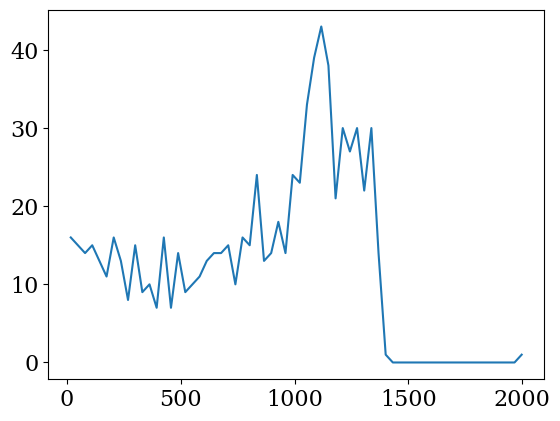

-0.8702623540884183
Elapsed time: 64.77 seconds


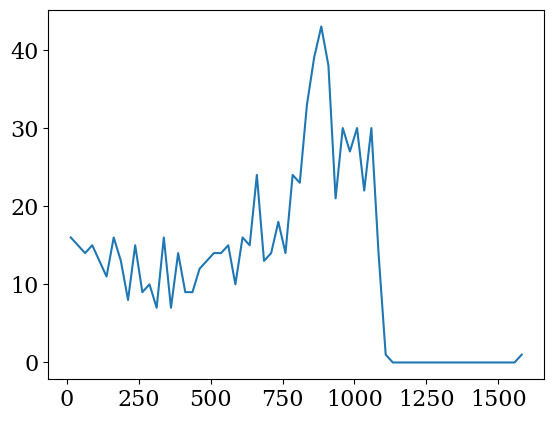

-0.8707122843936974
Elapsed time: 64.37 seconds


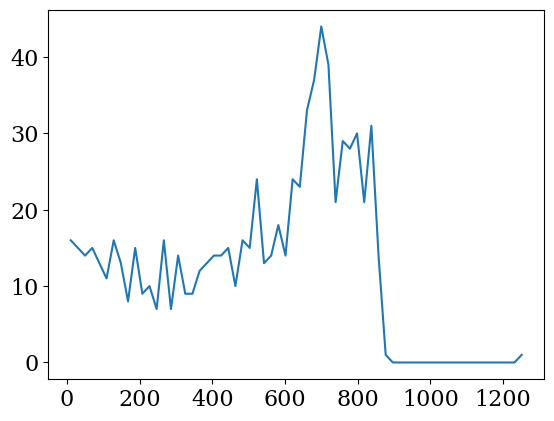

-0.8712820522420606
Elapsed time: 63.28 seconds


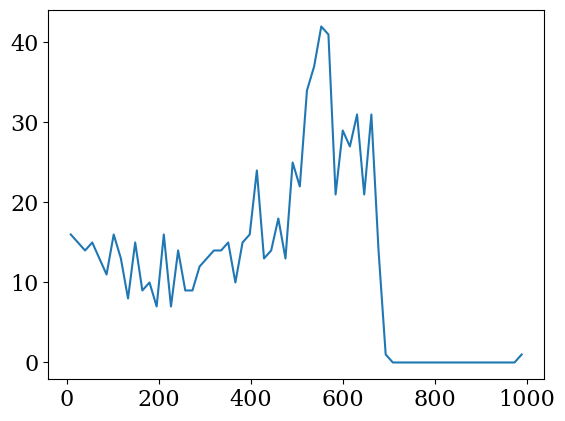

-0.8720065310420752
Elapsed time: 63.43 seconds


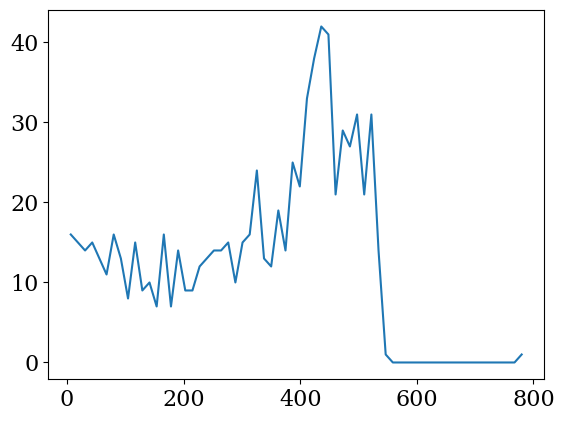

-0.8729279864554972
Elapsed time: 63.59 seconds


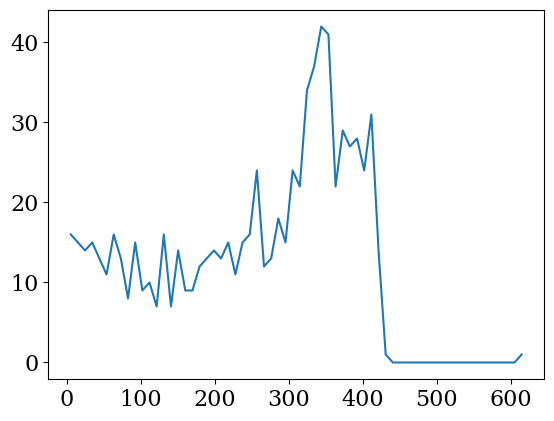

-0.8741030261193777
Elapsed time: 62.72 seconds


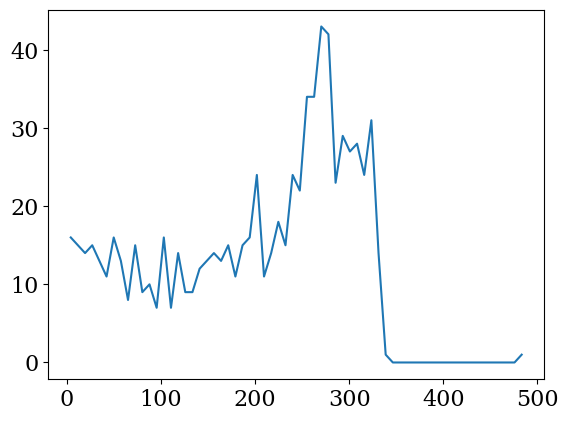

-0.8756065057678867
Elapsed time: 63.78 seconds


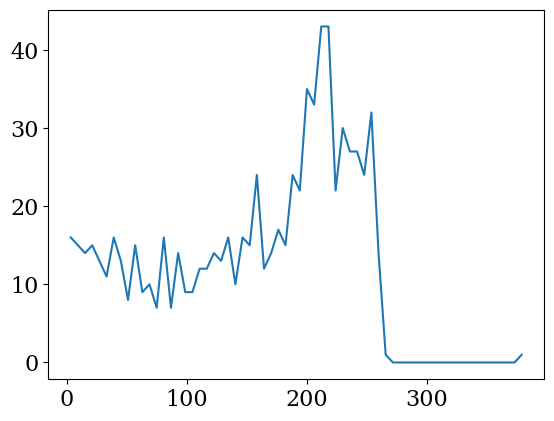

-0.8775365946962611
Elapsed time: 64.62 seconds


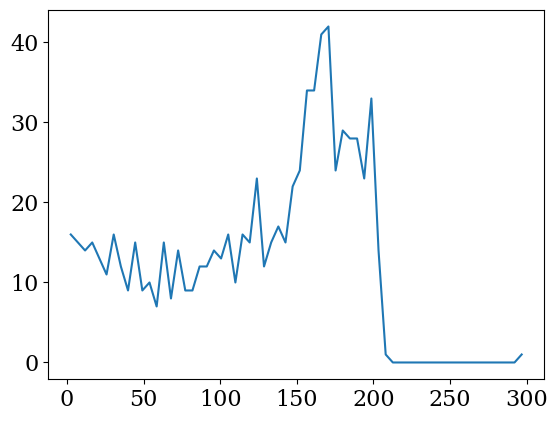

-0.8800248933588408
Elapsed time: 63.59 seconds


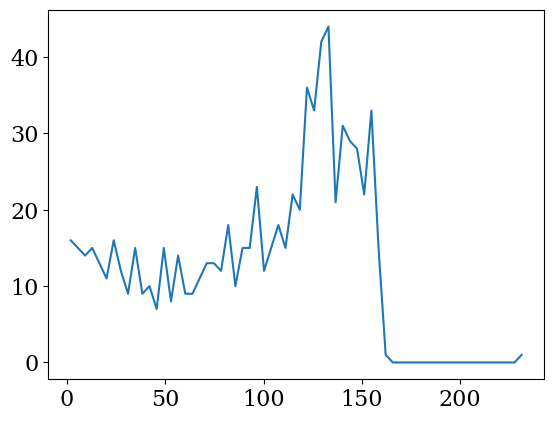

-0.8832519602110092
Elapsed time: 57.38 seconds


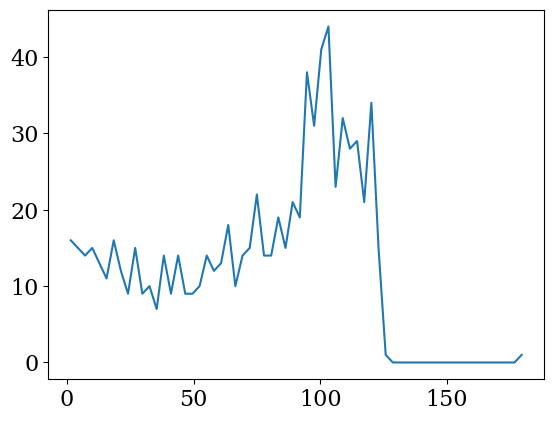

-0.8874686482469896
Elapsed time: 45.08 seconds


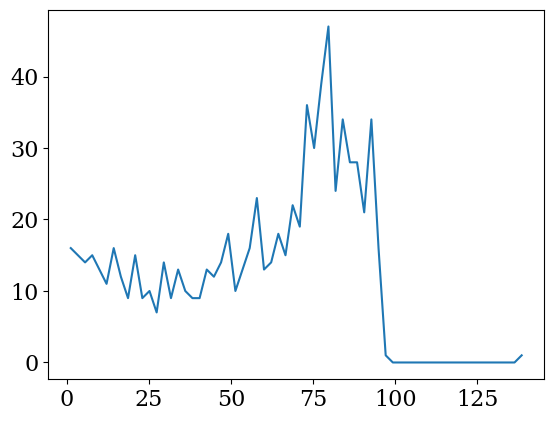

-0.8928908160086564
Elapsed time: 45.01 seconds


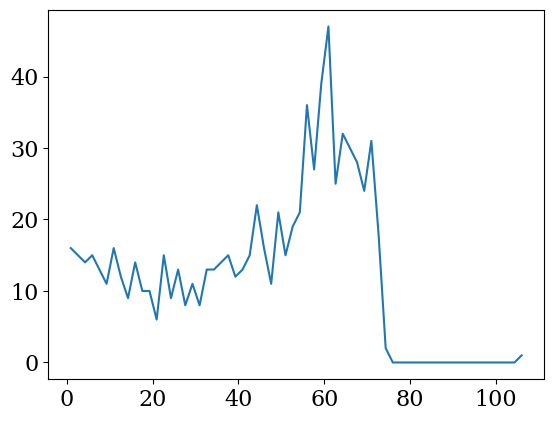

-0.8945215761543358
Elapsed time: 44.87 seconds


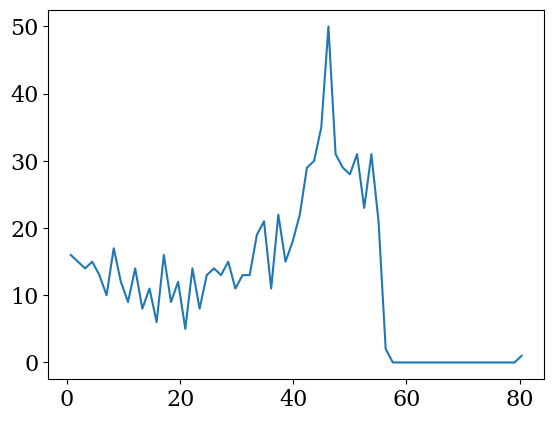

-0.8967303544244459
Elapsed time: 45.25 seconds


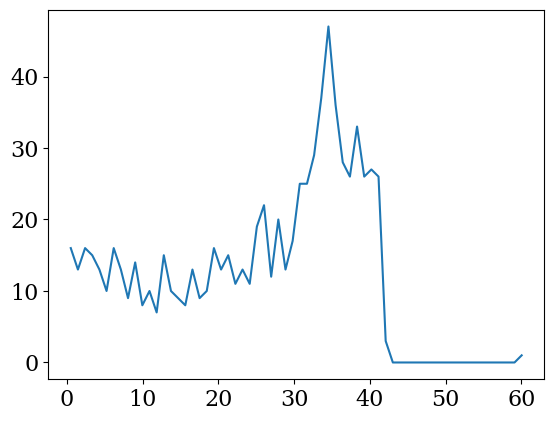

-0.8997856545471625
Elapsed time: 44.86 seconds


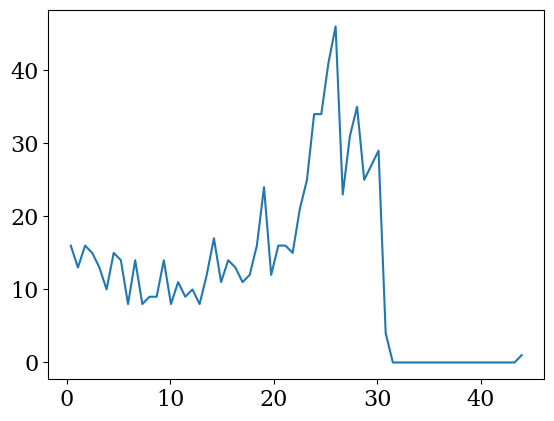

-0.9041454668320404
Elapsed time: 44.92 seconds


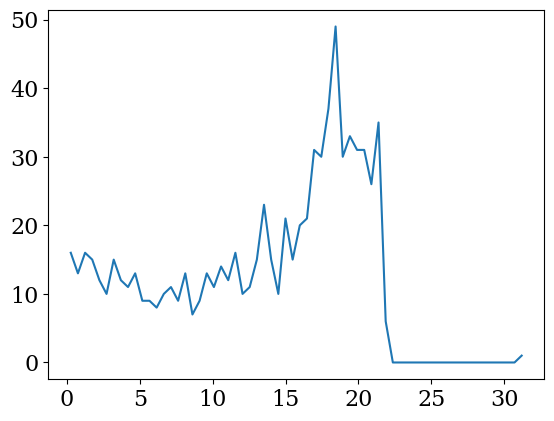

-0.9253056522597786
Elapsed time: 43.67 seconds


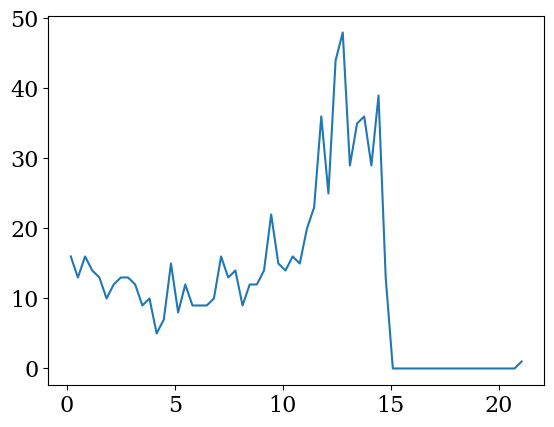

-0.9727125151713776
Elapsed time: 43.31 seconds


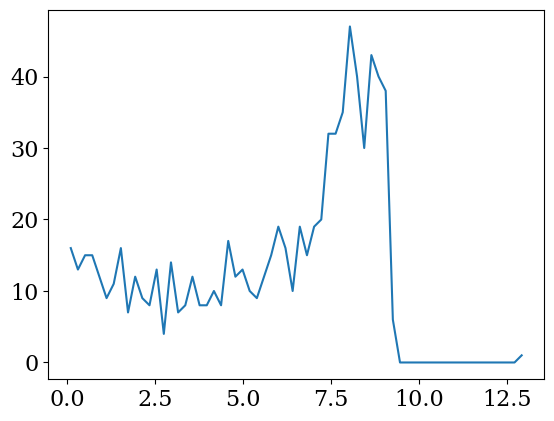

-1.0229279274920928
Elapsed time: 42.85 seconds


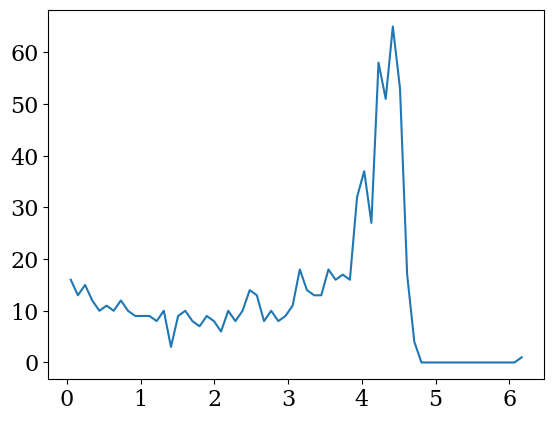

-1.1917434909577638
Elapsed time: 40.71 seconds


In [26]:
screening_dict['mode'] = 0
screening_dict['n_bins'] = n_bins

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=int)

  for k in range(num_loops):
    t_start = datetime.now()
    u_opt, idx_set, meas, fun_costs = optimizer.apg_opt(y_enc_train, Xt_train, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = datetime.now()
    time_delta = t_end - t_start
    time_proc[k] = time_delta.seconds*1e+6 + time_delta.microseconds

  time_min  = np.min(time_proc)*1e-6
  time_mean = np.mean(time_proc)*1e-6
  time_max  = np.max(time_proc)*1e-6

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred_test = util.multinomial_predict(Xt_test, u_opt)
  y_pred_train = util.multinomial_predict(Xt_train, u_opt)

  acc_test = np.sum(np.squeeze(y_test) - y_pred_test == 0)/y_test.shape[0]
  acc_train = np.sum(np.squeeze(y_train) - y_pred_train == 0)/y_train.shape[0]

  acc_test_vec.append(acc_test)
  acc_train_vec.append(acc_train)

# Results

In [27]:
os.makedirs("../results", exist_ok=True)

time_mat = np.reshape(time_mean_vec, [4,lmb_vec.shape[0]])
card_mat = np.reshape(card_vec, [4,lmb_vec.shape[0]])

red_gsafe_vec = card_mat[1,:] < 1
red_strong_vec = card_mat[2,:] < 1

acc_train_mat = np.reshape(acc_train_vec, [4,lmb_vec.shape[0]])
acc_test_mat = np.reshape(acc_test_vec, [4,lmb_vec.shape[0]])

## Cardinality

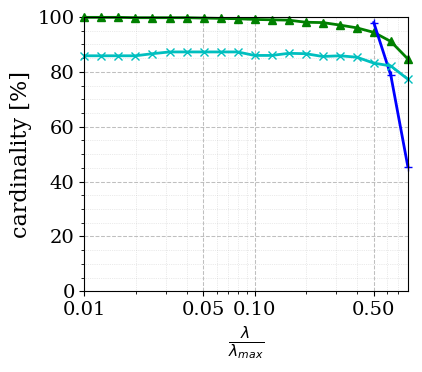

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [40]:
y_lim = (0,100)
x_lim = (np.min(lmb_r),np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5,4))

plt.semilogx(lmb_r[red_gsafe_vec], 100*card_mat[1,red_gsafe_vec], color='g', label='static-gapsafe', marker='^', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_strong_vec], 100*card_mat[2,red_strong_vec], color='b', label='static-strong', marker='+', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, 100*card_mat[3,:], color='c', label='proposed', marker='x', linewidth=2, clip_on=False)

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=10))

plt.xlim(x_lim)
plt.ylim(y_lim)

plt.legend(fancybox=True, shadow=True)
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("cardinality [%]")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('../results/fashionmnist-cardinality.eps', format='eps', bbox_inches='tight')

## Processing time

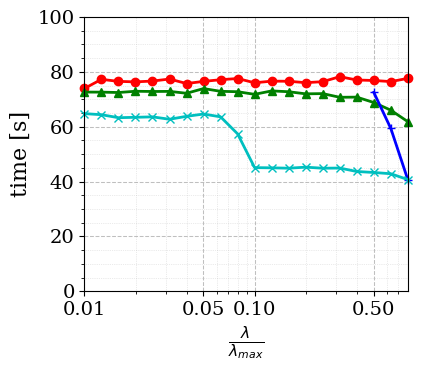

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [39]:
y_lim = (0,100)
x_lim = (np.min(lmb_r),np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5,4))

plt.semilogx(lmb_r, time_mat[0,:], color='r', label='vanilla', marker='o', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_gsafe_vec], time_mat[1,red_gsafe_vec], color='g', label='static-gapsafe', marker='^', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_strong_vec], time_mat[2,red_strong_vec], color='b', label='static-strong', marker='+', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, time_mat[3,:], color='c', label='proposed', marker='x', linewidth=2, clip_on=False)

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=10))

plt.xlim(x_lim)
plt.ylim(y_lim)

plt.legend(fancybox=True, shadow=True)
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("time [s]")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('../results/fashionmnist-time.eps', format='eps', bbox_inches='tight')

## Speedup

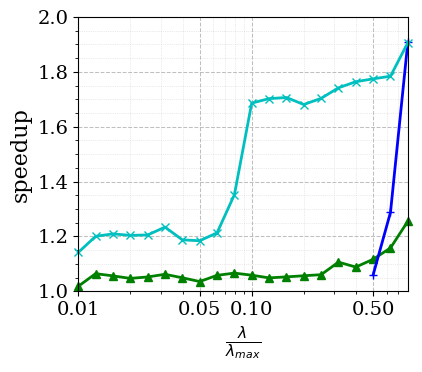

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [38]:
y_lim = (1,2)
x_lim = (np.min(lmb_r), np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5,4))

plt.semilogx(lmb_r[red_gsafe_vec], (time_mat[0,red_gsafe_vec]/time_mat[1,red_gsafe_vec]), color='g', label='static-gapsafe', marker='^', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_strong_vec], (time_mat[0,red_strong_vec]/time_mat[2,red_strong_vec]), color='b', label='static-strong', marker='+', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, (time_mat[0,:]/time_mat[3,:]), color='c', label='proposed', marker='x', linewidth=2, clip_on=False)

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=10))

plt.xlim(x_lim)
plt.ylim(y_lim)

plt.legend(fancybox=True, shadow=True)
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("speedup")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('../results/fashionmnist-speedup.eps', format='eps', bbox_inches='tight')

## Accuracy

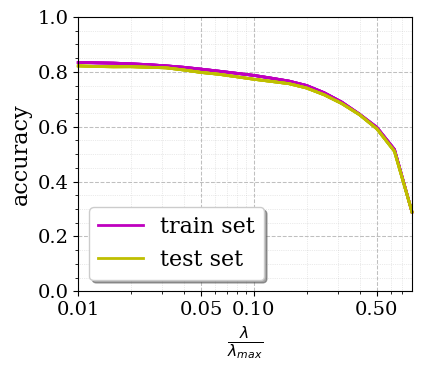

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [37]:
y_lim = (0,1)
x_lim = (np.min(lmb_r),np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5,4))

plt.semilogx(lmb_r, acc_train_mat[0,:], color='m', label='train set', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, acc_train_mat[1,:], color='m', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, acc_train_mat[2,:], color='m', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, acc_train_mat[3,:], color='m', linewidth=2, clip_on=False)

plt.semilogx(lmb_r, acc_test_mat[0,:], color='y', label='test set', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, acc_test_mat[1,:], color='y', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, acc_test_mat[2,:], color='y', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, acc_test_mat[3,:], color='y', linewidth=2, clip_on=False)

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=10))

plt.xlim(x_lim)
plt.ylim(y_lim)

plt.legend(loc='lower left', fancybox=True, shadow=True)
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("accuracy")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('../results/fashionmnist-acc.eps', format='eps', bbox_inches='tight')